# Regional ROI Export - flash-aurora Engine

Export clipped rollout predictions with **`rollout_and_export`** only (no separate `rollout_stream` step).

| Part | Preset | Demo |
| --- | --- | --- |
| **A** | `era5_pretrained` (0.25 deg) | `RoiBatch.example_batch()` - 4 rectangular ROIs: China, USA, Western Europe, North Africa |
| **B** | `hres_0.1` (0.1 deg) | Three U.S. states via **GeoJSON**, **shapefile**, and **raster** masks in [`docs/roi`](roi) |

Each call runs inference internally and writes one file tree per step. With `roi_batch=`, one pass exports every region (single GPU->CPU copy per step). **GeoTIFF** (`export_format="geotiff"`) is recommended for ROI output: each region is georeferenced (default Web Mercator EPSG:3857) and handles the 0/360 deg meridian correctly. Under the hood this uses **`RolloutStepWriter`** (mask clip + GeoTIFF write per step); you normally call `rollout_and_export` only, not the writer directly.

## Prerequisites

- **Part A:** CDS credentials; ~41 GiB peak reserved VRAM for 2 steps (`aurora-0.25-pretrained.ckpt`).
- **Part B:** UCAR RDA GRIB (or cache); ~56 GiB peak reserved for 2 steps (`aurora-0.1-finetuned.ckpt` + `aurora-0.1-static.pickle`).
- State ROI assets: `python scripts/build_roi_assets.py`.


## Shared paths

In [1]:
from pathlib import Path

from flash_aurora.engine.core.redaction import safe_path

ASSET_ROOT = Path("/root/autodl-tmp/aurora")
if ASSET_ROOT is None:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)
else:
    ASSET_ROOT = Path(ASSET_ROOT).expanduser().resolve()

ROI_DIR = (Path.cwd() / "roi").resolve()
if not (ROI_DIR / "manifest.json").is_file():
    ROI_DIR = (Path.cwd() / "docs" / "roi").resolve()
if not (ROI_DIR / "manifest.json").is_file():
    raise FileNotFoundError("docs/roi assets not found; run from docs/ or repo root")

print("asset_root:", safe_path(ASSET_ROOT))
print("roi_dir:", safe_path(ROI_DIR))


asset_root: ~/autodl-tmp/aurora
roi_dir: ~/flash-aurora/docs/roi


# Part A - 0.25 deg ERA5: four global regions

### A.1 Setup (`era5_pretrained`)


In [2]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.distributed import DistributedConfig
from flash_aurora.engine.egress import RoiBatch

ERA5_PRESET = "era5_pretrained"
ERA5_VALID_TIME = datetime(2026, 7, 1, 6)
TIME_INDEX = 1
ROLLOUT_STEPS = 2
INFERENCE_PRECISION = "bf16_mixed@fp32"
DISTRIBUTED = None
USE_HF_MIRROR = False

variant_025 = DEFAULT_PRESETS.get(ERA5_PRESET).variant
ckpt_025 = ASSET_ROOT / variant_025.checkpoint_filename

era5_downloader = DataDownloader.from_preset(ERA5_PRESET, asset_root=ASSET_ROOT)
era5_engine = AuroraEngine.from_preset(
    ERA5_PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=ckpt_025 if ckpt_025.is_file() else None,
    allow_hub_download=not ckpt_025.is_file(),
    hf_endpoint=HF_MIRROR_ENDPOINT if USE_HF_MIRROR and not ckpt_025.is_file() else None,
    inference_precision=INFERENCE_PRECISION,
    distributed=DISTRIBUTED,
)


### A.2 Download ERA5 (CDS)

In [3]:
import os
from pathlib import Path

missing = era5_downloader.missing(ERA5_VALID_TIME)
cds_api_key = os.environ.get("CDSAPI_KEY", "").strip() or None
# cds_api_key = "paste-your-cds-key-here"

has_cdsapirc = Path.home().joinpath(".cdsapirc").is_file()
if missing:
    print("Downloading missing ERA5 files:", missing)
    era5_downloader.ensure(
        ERA5_VALID_TIME,
        cds_api_key=cds_api_key,
        prompt=cds_api_key is None and not has_cdsapirc,
    )
else:
    print("ERA5 cache complete, skipping download")


ERA5 cache complete, skipping download


### A.3 IC, load, and export four regions

In [4]:
request = era5_downloader.ingest_request(ERA5_VALID_TIME, time_index=TIME_INDEX, download=False)
era5_batch = InitialConditionBuilder(era5_engine.config).from_source(request)
print("IC time:", era5_batch.metadata.time)

era5_engine.load(rollout_steps=ROLLOUT_STEPS)

region_batch = RoiBatch.example_batch()
export_dir = ASSET_ROOT / "output" / "roi_global"
paths = list(
    era5_engine.rollout_and_export(
        era5_batch,
        ROLLOUT_STEPS,
        export_dir=export_dir,
        roi_batch=region_batch,
        export_format="geotiff",
        variables=("2t",),
    )
)
print(f"exported {len(paths)} files ({len(region_batch.regions)} regions x {ROLLOUT_STEPS} steps)")
for path in paths:
    print(safe_path(path))


IC time: (datetime.datetime(2026, 7, 1, 6, 0),)
exported 8 files (4 regions x 2 steps)
~/autodl-tmp/aurora/output/roi_global/china/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_global/usa/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_global/western_europe/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_global/north_africa/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_global/china/prediction-001-2t.tif
~/autodl-tmp/aurora/output/roi_global/usa/prediction-001-2t.tif
~/autodl-tmp/aurora/output/roi_global/western_europe/prediction-001-2t.tif
~/autodl-tmp/aurora/output/roi_global/north_africa/prediction-001-2t.tif


### A.4 Visualize exported regions (2 m temperature, deg C)

Read step 0 GeoTIFF files written by `rollout_and_export` (no second inference pass). Bounds are reprojected to WGS84 for plotting.

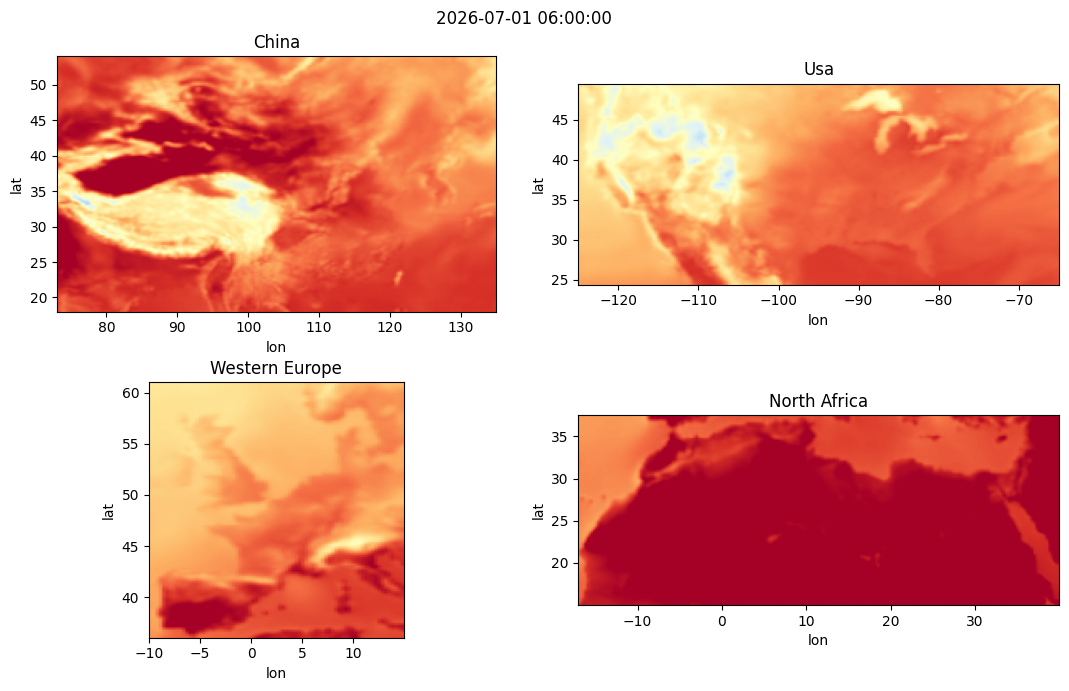

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.crs import CRS
from rasterio.warp import transform_bounds

SURFACE_VARIABLE = "2t"


def load_geotiff_celsius(path):
    with rasterio.open(path) as ds:
        data = ds.read(1).astype(np.float64)
        if ds.nodata is not None:
            data = np.where(data == ds.nodata, np.nan, data)
        data = data - 273.15
        west, south, east, north = ds.bounds
        if ds.crs is not None and ds.crs.to_epsg() == 3857:
            west, south, east, north = transform_bounds(
                ds.crs, CRS.from_epsg(4326), west, south, east, north
            )
    return data, west, east, south, north


fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, _mask) in zip(axs.flat, region_batch.regions):
    tif_path = export_dir / name / f"prediction-000-{SURFACE_VARIABLE}.tif"
    field_c, west, east, south, north = load_geotiff_celsius(tif_path)
    ax.imshow(
        field_c,
        origin="upper",
        extent=(west, east, south, north),
        vmin=-20,
        vmax=35,
        cmap="RdYlBu_r",
    )
    ax.set_title(name.replace("_", " ").title())
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

fig.suptitle(str(era5_batch.metadata.time[-1]))
plt.tight_layout()
plt.show()


### A.5 Release 0.25 deg engine


In [6]:
era5_engine.close()


---

# Part B - 0.1 deg HRES: four state-level ROIs

Uses bundled assets under `docs/roi/` for **California**, **Georgia**, **Michigan**, and **Texas**. Each state demonstrates one `Mask` factory: axis-aligned **bounds** (Georgia), **GeoJSON** (California), **shapefile** (Texas), **raster** (Michigan).

### B.1 Setup (`hres_0.1`)


In [7]:
from flash_aurora.engine.core.hub import HubDownloadOptions
from flash_aurora.engine.core.paths import AssetStore
from flash_aurora.engine.egress import Mask, RoiBatch

HRES_PRESET = "hres_0.1"
HRES_VALID_TIME = datetime(2022, 5, 11, 6)

variant_01 = DEFAULT_PRESETS.get(HRES_PRESET).variant
ckpt_01 = ASSET_ROOT / variant_01.checkpoint_filename

hres_downloader = DataDownloader.from_preset(HRES_PRESET, asset_root=ASSET_ROOT)
hres_engine = AuroraEngine.from_preset(
    HRES_PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=ckpt_01 if ckpt_01.is_file() else None,
    allow_hub_download=not ckpt_01.is_file(),
    hf_endpoint=HF_MIRROR_ENDPOINT if USE_HF_MIRROR and not ckpt_01.is_file() else None,
    inference_precision=INFERENCE_PRECISION,
    distributed=DISTRIBUTED,
)

static_pickle = ASSET_ROOT / variant_01.static_pickle
if not static_pickle.is_file():
    static_pickle = AssetStore(root=ASSET_ROOT).fetch_hub_file(
        variant_01.static_pickle,
        repo=variant_01.hf_repo,
        allow_download=True,
        explicit=ASSET_ROOT,
        hub=HubDownloadOptions(endpoint=HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None),
    )
print("static_pickle:", safe_path(static_pickle))


static_pickle: ~/autodl-tmp/aurora/aurora-0.1-static.pickle


### B.2 Download HRES 0.1 deg analysis (UCAR RDA)

In [8]:
missing_hres = hres_downloader.missing(HRES_VALID_TIME)
if missing_hres:
    print("Downloading:", missing_hres)
hres_downloader.ensure(HRES_VALID_TIME)
print("cache:", safe_path(hres_downloader.resolve_cache_dir()))


cache: ~/autodl-tmp/aurora/hres_0.1


### B.3 IC, load, and export three mask input types

In [9]:
hres_request = hres_downloader.ingest_request(HRES_VALID_TIME, time_index=TIME_INDEX, download=False)
hres_batch = InitialConditionBuilder(hres_engine.config).from_source(hres_request)
print("IC time:", hres_batch.metadata.time)

hres_engine.load(rollout_steps=ROLLOUT_STEPS)

state_batch = RoiBatch.from_mapping(
    {
        "california": Mask.from_geojson(ROI_DIR / "california.geojson"),
        "georgia": Mask.from_shapefile(ROI_DIR / "georgia" / "georgia.shp"),
        "texas": Mask.from_shapefile(ROI_DIR / "texas" / "texas.shp"),
        "michigan": Mask.from_raster(ROI_DIR / "michigan_mask.tif"),
    }
)
export_dir = ASSET_ROOT / "output" / "roi_hres_01"
paths = list(
    hres_engine.rollout_and_export(
        hres_batch,
        ROLLOUT_STEPS,
        export_dir=export_dir,
        roi_batch=state_batch,
        export_format="geotiff",
        variables=("2t",),
    )
)
print(f"exported {len(paths)} files")
for path in paths:
    print(safe_path(path))


IC time: (datetime.datetime(2022, 5, 11, 6, 0),)
exported 8 files
~/autodl-tmp/aurora/output/roi_hres_01/california/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_hres_01/georgia/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_hres_01/texas/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_hres_01/michigan/prediction-000-2t.tif
~/autodl-tmp/aurora/output/roi_hres_01/california/prediction-001-2t.tif
~/autodl-tmp/aurora/output/roi_hres_01/georgia/prediction-001-2t.tif
~/autodl-tmp/aurora/output/roi_hres_01/texas/prediction-001-2t.tif
~/autodl-tmp/aurora/output/roi_hres_01/michigan/prediction-001-2t.tif


### B.4 Visualize three mask input types

Load step 0 GeoTIFF per state.


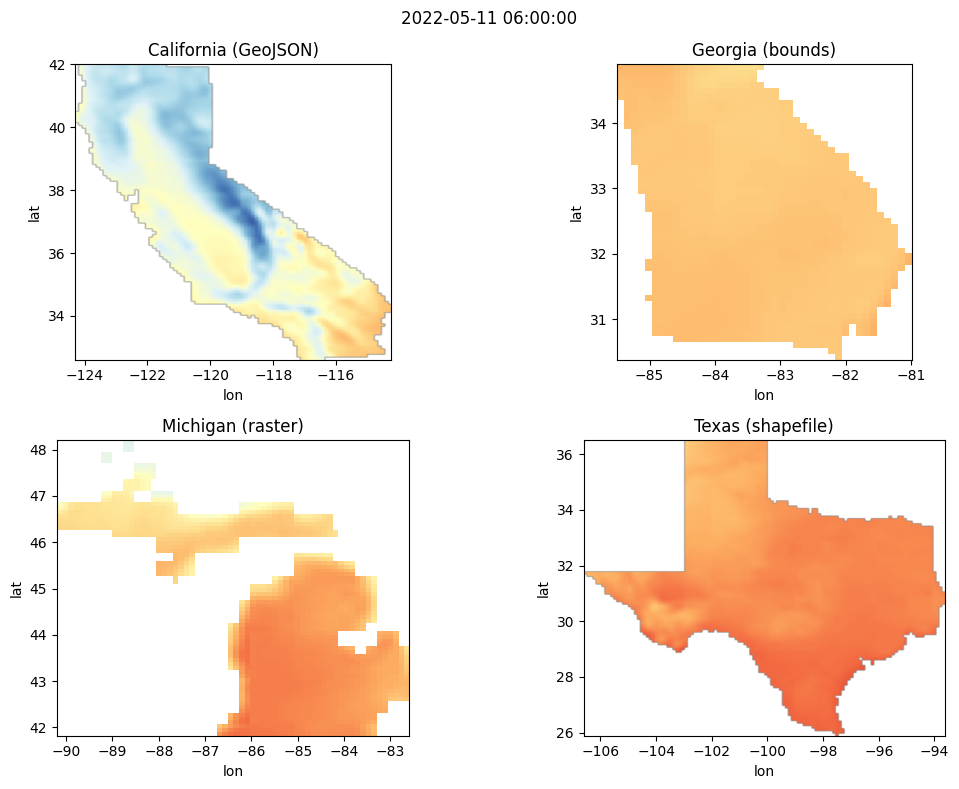

In [10]:
labels = [
    ("California (GeoJSON)", "california"),
    ("Georgia (bounds)", "georgia"),
    ("Michigan (raster)", "michigan"),
    ("Texas (shapefile)", "texas"),
]

fig, axs = plt.subplots(2, 2, figsize=(11, 8))
for ax, (title, slug) in zip(axs.flat, labels):
    tif_path = export_dir / slug / f"prediction-000-{SURFACE_VARIABLE}.tif"
    field_c, west, east, south, north = load_geotiff_celsius(tif_path)
    ax.imshow(
        field_c,
        origin="upper",
        extent=(west, east, south, north),
        vmin=-20,
        vmax=35,
        cmap="RdYlBu_r",
    )
    ax.set_title(title)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

fig.suptitle(str(hres_batch.metadata.time[-1]))
plt.tight_layout()
plt.show()


### B.5 Shutdown


In [11]:
hres_engine.close()
